# Web Scraping with BeautifulSoup and Selenium

Web scraping is the automated extraction of data from websites. In the social sciences it is increasingly used to build text corpora, study communication, and collect data that is publicly available online but not provided in a structured format.

This tutorial uses presidential debates from [debates.org](https://debates.org/) hosted by the Commission on Presidential Debates and Bluesky posts from [Hadley Wickham](https://bsky.app/profile/hadley.nz) as examples. By the end you will be able to:

- Fetch a webpage with the [`requests`](https://requests.readthedocs.io/en/latest/) library
- Parse its HTML with [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
- Navigate the HTML tree to extract the content you want
- Clean and save the extracted text
- Scale up to scrape multiple pages from the same site
- Use [Selenium](https://selenium-python.readthedocs.io/) to handle JavaScript-rendered pages and interactive sites

*Note: This tutorial assumes basic familiarity with Python, including variables, lists, dictionaries, loops, and functions. It was developed with assistance from [Claude Code](https://claude.ai/code).*

## Table of Contents
**Part 0: Before You Scrape**

1. Ethical and Legal Considerations

**Part 1: requests + BeautifulSoup**

2. Installation
3. Fetching a Webpage with `requests`
4. Parsing HTML with BeautifulSoup
5. Navigating the HTML Tree
6. Extracting the Debate Transcript
7. Cleaning the Text
8. Saving to File
9. Scaling Up: Scraping Multiple Transcripts

**Part 2: Selenium**

10. When to Use Selenium
11. Setting Up Selenium
12. Basic Navigation and Element Selection
13. Waits and Dynamic Content
14. Scraping Bluesky with Selenium

**15. Exercises**

## 1. Before You Scrape: Ethical and Legal Considerations

Before scraping any site, check three things:

1. **`robots.txt`**. Most sites publish a file at `/robots.txt` that specifies which paths automated crawlers may and may not access. Respecting it is standard practice.
2. **Terms of Service**. Some sites explicitly prohibit scraping in their ToS. Academic and non-commercial use is often permitted even when commercial use is not, but always check to make sure.
3. **Rate limiting**. Hammering a server with rapid requests is inconsiderate and can get your IP blocked. Always add a small delay between requests (see Section 9).

## 2. Installation

Libraries used in this tutorial:
- [`requests`](https://requests.readthedocs.io/en/latest/) for HTTP requests
- [`beautifulsoup4`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) for HTML parsing
- `lxml` for fast HTML/XML parser used by BeautifulSoup
- [`selenium`](https://selenium-python.readthedocs.io/) for browser automation (Part 2)

In [101]:
%pip install requests beautifulsoup4 lxml selenium

## 3. Fetching a Webpage with `requests`

The [`requests`](https://requests.readthedocs.io/en/latest/) library handles the HTTP layer. It sends a GET request to a URL and returns the server's response.

In [102]:
import requests

URL = "https://debates.org/voter-education/debate-transcripts/october-3-2012-debate-transcript/"

# A custom User-Agent identifies our request as coming from a research script,
# rather than appearing as an anonymous bot.
headers = {
    "User-Agent": "Mozilla/5.0 (research scraper; contact: your@email.com)"
}

response = requests.get(URL, headers=headers)

print(f"Status code : {response.status_code}")
print(f"Content-Type: {response.headers.get('Content-Type')}")
print(f"Page size   : {len(response.text):,} characters")

Status code : 200
Content-Type: text/html; charset=UTF-8
Page size   : 115,578 characters


### Understanding the status code

| Code | Meaning |
|------|-------------------------------------------|
| 200  | OK — request succeeded |
| 403  | Forbidden — server refused the request |
| 404  | Not Found — the URL does not exist |
| 429  | Too Many Requests — you are being rate-limited |
| 5xx  | Server error — try again later |

We can also call `response.raise_for_status()`. This tells requests: "if the status code indicates an error (anything 4xx or 5xx), raise an exception so the program stops and tells me something went wrong."

In [103]:
# Safe pattern: raise immediately if something went wrong
response.raise_for_status()

# Peek at the raw HTML
print(response.text[:500])

<!DOCTYPE html PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN">
<html>
    <head>
        <meta http-equiv="Content-Language" content="en-us"/>
        <meta http-equiv="Content-Type" content="text/html;charset=utf-8"/>
        <title>CPD: October 3, 2012 Debate Transcript</title>
        <link href="/wp-content/themes/debates2019/css/reset.css" rel="stylesheet" type="text/css"/>
        <link href="/wp-content/themes/debates2019/css/jc-main.css" rel="stylesheet" type="text/css" media="screen,pr


## 4. Parsing HTML with BeautifulSoup

Raw HTML is a string. [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) parses it into a tree of objects you can query and navigate.

In [104]:
from bs4 import BeautifulSoup

# 'lxml' is the fastest parser; 'html.parser' is built-in but slower
soup = BeautifulSoup(response.text, "lxml")

print(type(soup))
print("Page title:", soup.title.string)

<class 'bs4.BeautifulSoup'>
Page title: CPD: October 3, 2012 Debate Transcript


### How BeautifulSoup represents HTML

Each HTML element becomes a `Tag` object with:
- `.name`: the tag name (e.g. `'div'`, `'p'`)
- `.attrs`: a dictionary of attributes (e.g. `{'id': 'content-sm'}`)
- `.string` / `.get_text()`: the text content
- `.children`, `.parent`, `.next_sibling`: tree navigation

You find elements with two main methods:
- `soup.find(tag, attrs)`: returns the **first** match
- `soup.find_all(tag, attrs)`: returns a **list** of all matches

Full reference: [BeautifulSoup documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#searching-the-tree)

## 5. Navigating the HTML Tree

Before extracting anything, it helps to understand the page structure. Open the URL in a browser, right-click on the text you want, and choose "Inspect" to see which element contains it.

For this page the debate text lives inside `<div id="content-sm">`.

In [105]:
# Find by tag name
first_p = soup.find("p")
print("First <p>:", first_p.get_text()[:80])

# Find by id attribute
content_div = soup.find("div", id="content-sm")
print("\nFound content div:", content_div is not None)

# Find by CSS class
# soup.find("div", class_="some-class")  # note: class_ not class (reserved word)

# Count all <p> tags on the whole page
all_p = soup.find_all("p")
print(f"\nTotal <p> tags on page: {len(all_p)}")

# Count <p> tags only inside the content div
content_p = content_div.find_all("p")
print(f"<p> tags inside content div: {len(content_p)}")

First <p>: PRESIDENT BARACK OBAMA AND FORMER GOV. MITT ROMNEY, R-MASS., PRESIDENTIAL CANDID

Found content div: True

Total <p> tags on page: 478
<p> tags inside content div: 477


## 6. Extracting the Debate Transcript

Now we know where the content lives, we can extract it. The transcript text is split across `<p>` tags inside `<div id="content-sm">`.

In [106]:
# Extract the page title
title = soup.find("h1").get_text(strip=True)
print("Title:", title)

# Extract all paragraph text from the content div
paragraphs = [p.get_text(strip=True) for p in content_p]

# Preview the first few
for i, para in enumerate(paragraphs[:6]):
    print(f"\n[{i}] {para[:120]}")

Title: October 3, 2012 Debate Transcript

[0] PRESIDENT BARACK OBAMA AND FORMER GOV. MITT ROMNEY,R-MASS., PRESIDENTIAL CANDIDATE, PARTICIPATE IN ACANDIDATES DEBATE, U

[1] OCTOBER 3, 2012

[2] SPEAKERS: FORMER GOV. MITT ROMNEY, R-MASS.

[3] PRESIDENT BARACK OBAMA

[4] JIM LEHRER, MODERATOR

[5] LEHRER: Good evening from the Magness Arena at the University of Denver in Denver, Colorado. I’m Jim Lehrer of the “PBS 


### Identifying speakers

Each turn starts with a speaker label in the format `SPEAKER: text`. We can detect these with a regular expression.

In [107]:
import re

# Pattern: optional whitespace, ALL-CAPS WORD(S), colon
SPEAKER_RE = re.compile(r'^([A-Z][A-Z\s\.]+):\s*')

turns = []
for para in paragraphs:
    match = SPEAKER_RE.match(para)
    if match:
        speaker = match.group(1).strip()
        text    = para[match.end():].strip()
        turns.append({"speaker": speaker, "text": text})

print(f"Found {len(turns)} speaker turns\n")
for turn in turns[:10]:
    print(f"[{turn['speaker']}]  {turn['text'][:100]}")

Found 207 speaker turns

[SPEAKERS]  FORMER GOV. MITT ROMNEY, R-MASS.
[LEHRER]  Good evening from the Magness Arena at the University of Denver in Denver, Colorado. I’m Jim Lehrer 
[LEHRER]  This debate and the next three — two presidential, one vice presidential — are sponsored by the Comm
[LEHRER]  You have two minutes. Each of you have two minutes to start. A coin toss has determined, Mr. Preside
[OBAMA]  Well, thank you very much, Jim, for this opportunity. I want to thank Governor Romney and the Univer
[LEHRER]  Governor Romney, two minutes.
[ROMNEY]  Thank you, Jim. It’s an honor to be here with you, and I appreciate the chance to be with the presid
[ROMNEY]  Now, I’m concerned that the path that we’re on has just been unsuccessful. The president has a view 
[LEHRER]  Mr. President, please respond directly to what the governor just said about trickle-down — his trick
[OBAMA]  Well, let me talk specifically about what I think we need to do. First, we’ve got to improve our edu


In [108]:
from collections import Counter

speaker_counts = Counter(t["speaker"] for t in turns)
print("Turn counts per speaker:")
for speaker, count in speaker_counts.most_common():
    print(f"  {speaker:10s}  {count}")

# Word counts per speaker
word_counts = Counter()
for turn in turns:
    word_counts[turn["speaker"]] += len(turn["text"].split())

print("\nWord counts per speaker:")
for speaker, count in word_counts.most_common():
    print(f"  {speaker:10s}  {count:,}")

Turn counts per speaker:
  LEHRER      80
  ROMNEY      71
  OBAMA       55
  SPEAKERS    1

Word counts per speaker:
  ROMNEY      2,368
  OBAMA       1,890
  LEHRER      1,280
  SPEAKERS    5


## 7. Cleaning the Text

Raw scraped text often needs cleaning before analysis. Common issues:
- HTML entities (`&amp;` → `&`, `&#8217;` → `'`)
- Non-breaking spaces (`\xa0`)
- Stage directions `(APPLAUSE)`, `(LAUGHTER)`, `(CROSSTALK)`
- Extra whitespace

In [109]:
import html

def clean_text(text: str) -> str:
    text = html.unescape(text)                     # decode HTML entities
    text = text.replace("\xa0", " ")               # non-breaking spaces
    text = re.sub(r"\([A-Z ]+\)", "", text)        # stage directions
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace
    return text

# Apply to all turns
for turn in turns:
    turn["text"] = clean_text(turn["text"])

raw_example = """
Governor Romney has a perspective that says if we cut taxes, skewed towards the wealthy, and roll back regulations, that we&#8217;ll be better off.
I&#8217;ve got a different view.
"""
print("Before:", raw_example[:200])
print("After: ", clean_text(raw_example)[:200])

Before: 
Governor Romney has a perspective that says if we cut taxes, skewed towards the wealthy, and roll back regulations, that we&#8217;ll be better off.
I&#8217;ve got a different view.

After:  Governor Romney has a perspective that says if we cut taxes, skewed towards the wealthy, and roll back regulations, that we’ll be better off. I’ve got a different view.


## 8. Saving to File

Save the transcript in two formats: plain text (for readability) and structured JSON for analysis.

In [110]:
# Plain text — readable transcript
with open("debate_2012_oct3.txt", "w", encoding="utf-8") as f:
    f.write(title + "\n")
    f.write("=" * len(title) + "\n\n")
    for turn in turns:
        f.write(f"{turn['speaker']}: {turn['text']}\n\n")

print("Saved debate_2012_oct3.txt")

Saved debate_2012_oct3.txt


In [111]:
import json

debate_data = {"title": title, "url": URL, "turns": turns}

with open("debate_2012_oct3.json", "w", encoding="utf-8") as f:
    json.dump(debate_data, f, indent=2, ensure_ascii=False)

print("Saved debate_2012_oct3.json")
print(f"  {len(turns)} turns, {sum(len(t['text'].split()) for t in turns):,} words")

Saved debate_2012_oct3.json
  207 turns, 5,542 words


## 9. Scaling Up

The sidebar of the debates.org page contains links to all available transcripts. We can scrape that list automatically and loop over each URL.

This section introduces two important practices:
- **Extracting links** from a navigation list
- **Polite crawling** — adding a delay between requests

In [112]:
# Step 1: find all transcript links from the sidebar
BASE_URL = "https://debates.org"

left_menu = soup.find("div", id="leftmenu")
transcript_links = [
    {"text": a.get_text(strip=True), "url": BASE_URL + a["href"]}
    for a in left_menu.find_all("a")
    if "/voter-education/debate-transcripts/" in a.get("href", "")
    and "translations" not in a.get("href", "")
]

print(f"Found {len(transcript_links)} transcript links\n")
for link in transcript_links[:5]:
    print(f"  {link['text']}")
    print(f"  {link['url']}\n")

Found 48 transcript links

  Debate Transcripts
  https://debates.org/voter-education/debate-transcripts/

  October 07, 2020 Vice Presidential Debate Transcript
  https://debates.org/voter-education/debate-transcripts/vice-presidential-debate-at-the-university-of-utah-in-salt-lake-city-utah/

  October 22, 2020 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/october-22-2020-debate-transcript/

  September 29, 2020 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/september-29-2020-debate-transcript/

  October 19, 2016 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/october-19-2016-debate-transcript/



It looks like debate transcripts have dates, while other pages don't. Let's only collect urls of debate transcripts.

In [113]:
# Step 2: filter to links with dates
import re

transcript_links = [
    {"text": a.get_text(strip=True), "url": BASE_URL + a["href"]}
    for a in left_menu.find_all("a")
    if "/voter-education/debate-transcripts/" in a.get("href", "")
    and "translations" not in a.get("href", "")
    and re.search(r'\d{4}', a.get_text())  # only links with a year in the text
    ]

print(f"Found {len(transcript_links)} transcript links\n")
for link in transcript_links[:5]:
    print(f"  {link['text']}")
    print(f"  {link['url']}\n")

Found 47 transcript links

  October 07, 2020 Vice Presidential Debate Transcript
  https://debates.org/voter-education/debate-transcripts/vice-presidential-debate-at-the-university-of-utah-in-salt-lake-city-utah/

  October 22, 2020 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/october-22-2020-debate-transcript/

  September 29, 2020 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/september-29-2020-debate-transcript/

  October 19, 2016 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/october-19-2016-debate-transcript/

  October 9, 2016 Debate Transcript
  https://debates.org/voter-education/debate-transcripts/october-9-2016-debate-transcript/



In [114]:
import time

def scrape_transcript(url: str, fallback_title: str = "Unknown") -> dict:
    r = requests.get(url, headers=headers)
    r.raise_for_status()

    page_soup   = BeautifulSoup(r.text, "lxml")
    content_div = page_soup.find("div", id="content-sm")
    if not content_div:
        return {}

    title_tag  = page_soup.find("h1")
    title      = title_tag.get_text(strip=True) if title_tag else fallback_title
    paragraphs = [p.get_text(strip=True) for p in content_div.find_all("p")]

    turns = []
    for para in paragraphs:
        match = SPEAKER_RE.match(para)
        if match:
            turns.append({
                "speaker": match.group(1).strip(),
                "text":    clean_text(para[match.end():])
            })

    return {"title": title, "url": url, "turns": turns}


# Scrape the first 3 transcripts as a demo
corpus = []
for link in transcript_links[:3]:
    print(f"Scraping: {link['text']}...")
    data = scrape_transcript(link["url"], fallback_title=link["text"])
    if data:
        corpus.append(data)
        print(f"  → {len(data['turns'])} turns, "
              f"{sum(len(t['text'].split()) for t in data['turns']):,} words")
    time.sleep(2)  # be polite

print(f"\nCorpus: {len(corpus)} debates")

Scraping: October 07, 2020 Vice Presidential Debate Transcript...
  → 246 turns, 14,926 words
Scraping: October 22, 2020 Debate Transcript...
  → 354 turns, 17,997 words
Scraping: September 29, 2020 Debate Transcript...
  → 858 turns, 17,263 words

Corpus: 3 debates


In [115]:
with open("debate_corpus.json", "w", encoding="utf-8") as f:
    json.dump(corpus, f, indent=2, ensure_ascii=False)

print("Saved debate_corpus.json\n")
for debate in corpus:
    speakers = Counter(t["speaker"] for t in debate["turns"])
    words    = sum(len(t["text"].split()) for t in debate["turns"])
    print(f"  {debate['title'][:50]}")
    print(f"    words: {words:,}   speakers: {dict(speakers.most_common(3))}")

Saved debate_corpus.json

  October 07, 2020 Vice Presidential Debate Transcri
    words: 14,926   speakers: {'PAGE': 93, 'PENCE': 89, 'HARRIS': 62}
  October 22, 2020 Debate Transcript
    words: 17,997   speakers: {'WELKER': 146, 'TRUMP': 122, 'BIDEN': 84}
  September 29, 2020 Debate Transcript
    words: 17,263   speakers: {'TRUMP': 341, 'BIDEN': 269, 'WALLACE': 246}


In [137]:
with open(SAVE_DIR + "debate_corpus.json", "w", encoding="utf-8") as f:
    json.dump(corpus, f, indent=2, ensure_ascii=False)

print(f"Saved debate_corpus.json ({len(corpus)} debates)")

Saved debate_corpus.json (3 debates)


## Data Visualization

Now that we have the processed text, let's look at some basic descriptive statistics.

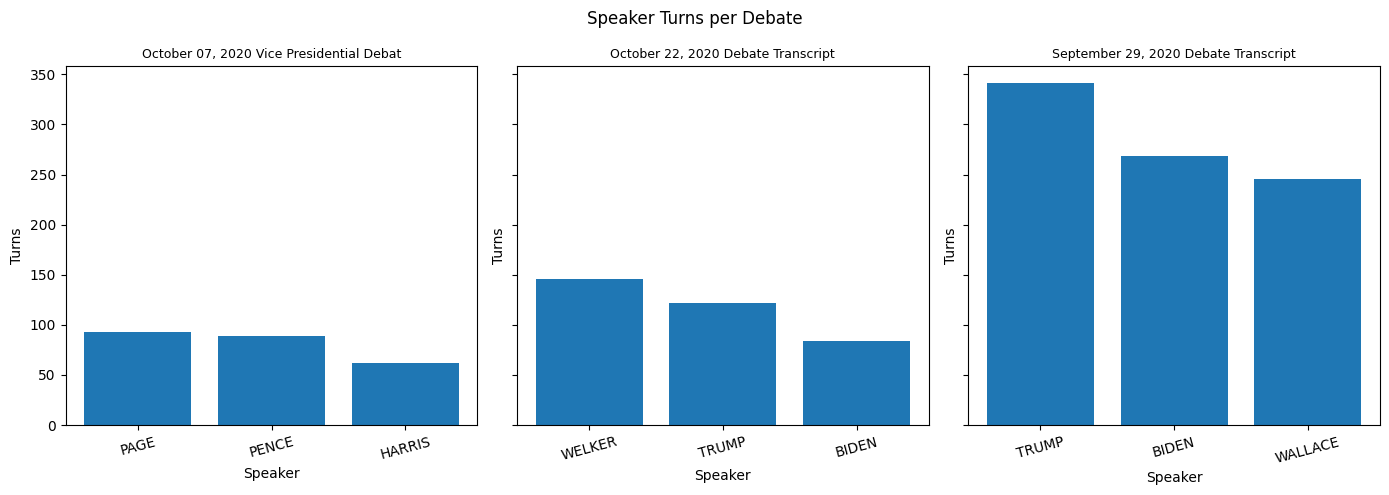

In [116]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(corpus), figsize=(14, 5), sharey=True)

for ax, debate in zip(axes, corpus):
    speaker_counts = Counter(t["speaker"] for t in debate["turns"])
    top = [(s, c) for s, c in speaker_counts.most_common() if c > 1]
    if not top:
        continue
    names, counts = zip(*top)

    ax.bar(names, counts)
    ax.set_title(debate["title"][:40], fontsize=9)
    ax.set_xlabel("Speaker")
    ax.set_ylabel("Turns")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Speaker Turns per Debate", fontsize=12)
plt.tight_layout()
plt.show()

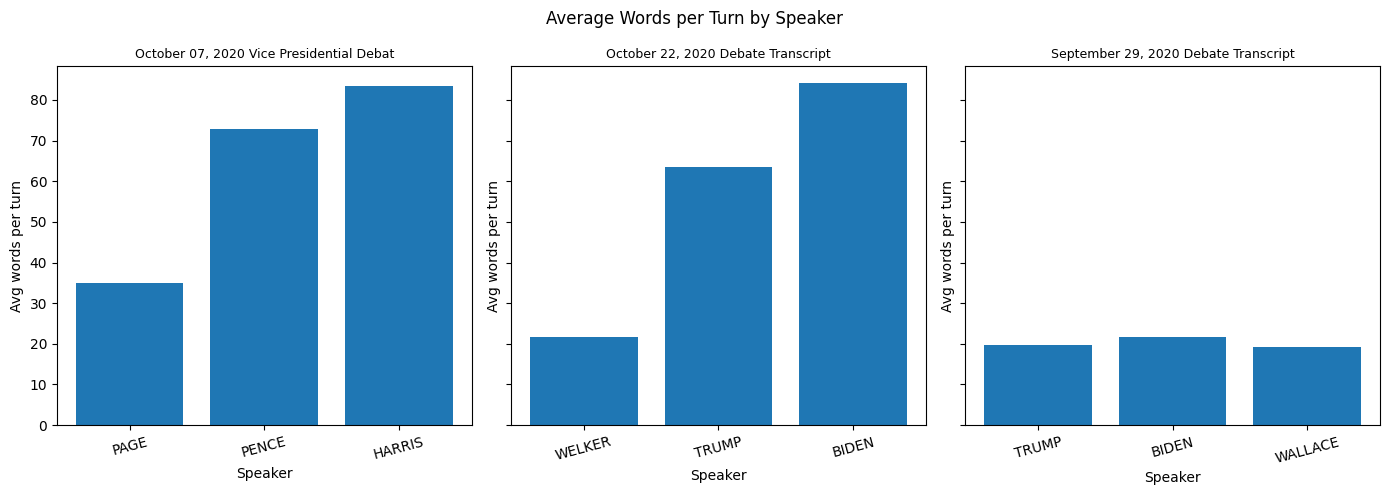

In [117]:
fig, axes = plt.subplots(1, len(corpus), figsize=(14, 5), sharey=True)

for ax, debate in zip(axes, corpus):
    speaker_counts = Counter(t["speaker"] for t in debate["turns"])
    word_totals = Counter()
    for t in debate["turns"]:
        word_totals[t["speaker"]] += len(t["text"].split())

    top_speakers = [s for s, _ in speaker_counts.most_common() if speaker_counts[s] > 1]
    avg_words = [word_totals[s] / speaker_counts[s] for s in top_speakers]

    ax.bar(top_speakers, avg_words)
    ax.set_title(debate["title"][:40], fontsize=9)
    ax.set_xlabel("Speaker")
    ax.set_ylabel("Avg words per turn")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Average Words per Turn by Speaker", fontsize=12)
plt.tight_layout()
plt.show()

## Part 2 — Selenium

## 10. When to Use Selenium

`requests` + BeautifulSoup works by downloading the raw HTML the server sends. This is fast and simple, but it only sees the initial HTML. Any content rendered by JavaScript after the page loads will be missing.

[Selenium](https://www.selenium.dev/documentation/webdriver/) launches a real browser (Chrome, Firefox, etc.) and controls it programmatically, so it sees the page exactly as a human user would, including any content added by JavaScript.

| Situation | Use |
|---|---|
| Static HTML page (like debates.org) | `requests` + BeautifulSoup ✓ |
| Content loaded by JavaScript after page load | Selenium ✓ |
| Infinite scroll / "Load more" buttons | Selenium ✓ |
| Login required before accessing content | Selenium ✓ |
| Filling in search forms or dropdowns | Selenium ✓ |
| Large-scale crawling of static pages | `requests` + BeautifulSoup (faster) ✓ |

A common pattern is the **hybrid approach**: use Selenium to render the page, then pass `driver.page_source` to BeautifulSoup for parsing — combining Selenium's rendering power with BeautifulSoup's convenient API.

## 11. Setting Up Selenium

Selenium requires a **browser driver**, a small executable that lets Python control the browser. Since Selenium 4.6, the built-in Selenium Manager handles driver installation automatically. In Google Colab, we still need to install the Chromium browser itself.

Reference: [Selenium installation guide](https://selenium-python.readthedocs.io/installation.html)

In [118]:
# Install Google Chrome in Colab (skip if running locally with Chrome already installed)
import sys
if "google.colab" in sys.modules:
    !wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
    !apt-get install -y ./google-chrome-stable_current_amd64.deb -qq
    print("Chrome installed")
else:
    print("Not in Colab — using local Chrome installation")

Chrome installed


In [119]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

def make_driver(headless: bool = True) -> webdriver.Chrome:
    """Create a configured Chrome WebDriver."""
    options = Options()
    if headless:
        options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920,1080")
    options.add_argument(
        "user-agent=Mozilla/5.0 (research scraper; contact: your@email.com)"
    )
    # No binary_location or Service needed — Selenium Manager finds the matching
    # chromedriver automatically for a standard Google Chrome install.
    return webdriver.Chrome(options=options)

driver = make_driver()
print("Driver created:", driver.capabilities["browserName"],
      driver.capabilities.get("browserVersion", ""))

Driver created: chrome 148.0.7778.178


## 12. Basic Navigation and Element Selection

Selenium's core navigation methods:

| Method | Description |
|---|---|
| `driver.get(url)` | Navigate to a URL |
| `driver.page_source` | Get the current page's full HTML |
| `driver.title` | Get the page title |
| `driver.current_url` | Get the current URL |
| `driver.back()` / `driver.forward()` | Browser navigation |
| `driver.quit()` | Close the browser |

Elements are found using `find_element()` (first match) and `find_elements()` (all matches), both from `selenium.webdriver.common.by.By`.

Reference: [Selenium locator strategies](https://www.selenium.dev/documentation/webdriver/elements/locators/)

In [120]:
from selenium.webdriver.common.by import By

driver.get(URL)
print("Title  :", driver.title)
print("URL    :", driver.current_url)
print("HTML   :", len(driver.page_source), "chars")

Title  : CPD: October 3, 2012 Debate Transcript
URL    : https://debates.org/voter-education/debate-transcripts/october-3-2012-debate-transcript/
HTML   : 109440 chars


In [121]:
# --- Finding elements ---

# By ID  (equivalent to soup.find('div', id='content-sm'))
content_div = driver.find_element(By.ID, "content-sm")
print("Found content div:", content_div.tag_name)

# By CSS selector  (equivalent to soup.select('#content-sm p'))
paragraphs_sel = driver.find_elements(By.CSS_SELECTOR, "#content-sm p")
print(f"Paragraphs via CSS selector: {len(paragraphs_sel)}")

# By tag name
heading = driver.find_element(By.TAG_NAME, "h1")
print("H1 text:", heading.text)

# Getting text and attributes from an element
first_link = driver.find_element(By.CSS_SELECTOR, "#leftmenu a")
print("First sidebar link text:", first_link.text)
print("First sidebar link href:", first_link.get_attribute("href"))

Found content div: div
Paragraphs via CSS selector: 478
H1 text: October 3, 2012 Debate Transcript
First sidebar link text: Debate Videos
First sidebar link href: https://debates.org/voter-education/debate-videos/


### Locator strategies at a glance

| `By.*` | Example | Equivalent CSS/HTML |
|---|---|---|
| `By.ID` | `By.ID, "content-sm"` | `#content-sm` |
| `By.CLASS_NAME` | `By.CLASS_NAME, "lmtop"` | `.lmtop` |
| `By.TAG_NAME` | `By.TAG_NAME, "h1"` | `h1` |
| `By.CSS_SELECTOR` | `By.CSS_SELECTOR, "#content-sm p"` | any CSS selector |
| `By.XPATH` | `By.XPATH, "//div[@id='content-sm']//p"` | XPath expression |
| `By.LINK_TEXT` | `By.LINK_TEXT, "Debate Videos"` | exact `<a>` text |

CSS selectors are usually the most readable. XPath is more powerful for complex traversals (e.g. "find a `<p>` that follows an `<h2>` containing the word 'Taxes'").

## 13. Waits and Dynamic Content

When a page uses JavaScript, elements may not exist in the DOM the moment `driver.get()` returns. Trying to find them immediately raises a `NoSuchElementException`.

Selenium provides two types of waits. Reference: [Selenium waits documentation](https://selenium-python.readthedocs.io/waits.html)

### Implicit wait
Tells the driver to poll the DOM for up to N seconds before raising an error. Set it once and it applies globally.

In [122]:
# Implicit wait: retry all find_element calls for up to 5 seconds
driver.implicitly_wait(5)
print("Implicit wait set to 5 seconds")

Implicit wait set to 5 seconds


### Explicit wait

More precise. Wait for a *specific condition* on a *specific element*. Use this when you know exactly what signal indicates the page is ready.

In [123]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Reload the page and wait until the content div is present
driver.get(URL)

wait = WebDriverWait(driver, timeout=10)

# Wait until the element is present in the DOM
content_div = wait.until(
    EC.presence_of_element_located((By.ID, "content-sm"))
)
print("Content div found after wait:", content_div.tag_name)

# Other useful expected conditions:
# EC.visibility_of_element_located(...)  — element exists AND is visible
# EC.element_to_be_clickable(...)        — element is visible and enabled
# EC.text_to_be_present_in_element(...)  — element contains specific text
# EC.staleness_of(element)               — wait for an element to disappear (e.g. after a reload)

Content div found after wait: div


### Simulating user interactions

Selenium can click buttons, type into fields, scroll, and more — useful when content only appears after interaction.

In [124]:
from selenium.webdriver.common.action_chains import ActionChains

# Scroll to the bottom of the page (useful for infinite-scroll sites)
driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
print("Scrolled to bottom")

# Scroll back to top
driver.execute_script("window.scrollTo(0, 0);")

# Click an element
# button = driver.find_element(By.CSS_SELECTOR, "button.load-more")
# button.click()

# Type into a text input
# search_box = driver.find_element(By.NAME, "q")
# search_box.send_keys("Obama Romney debate")
# search_box.submit()

Scrolled to bottom


## 14. When Selenium is the only option

To illustrate when `requests` would fail, consider a site that loads its content via a JavaScript API call after page load. The raw HTML from `requests` would contain something like:

```html
<div id="transcript">
  <!-- content loaded by script -->
</div>
```

BeautifulSoup would find an empty div. Selenium, however, waits for the script to run and the div to be populated, so `driver.find_elements(By.CSS_SELECTOR, "#transcript p")` would return the actual transcript paragraphs.

Common real-world examples:
- Social media timelines (Twitter/X, Facebook)
- Search result pages that paginate via JavaScript
- News sites with comment sections loaded asynchronously
- Government data portals with filter dropdowns that trigger API calls

### Demo: Bluesky

[Bluesky](https://bsky.app) is a social media platform built on the open AT Protocol. Its web app is a React single-page application; the server sends a bare HTML shell and JavaScript populates all the content after load. This makes it a good real-world example of when `requests` + BeautifulSoup fails and Selenium is required.

> **Note for research use:** Bluesky exposes a public API at `https://public.api.bsky.app`. For collecting data at scale, querying the API directly is more reliable than scraping. The demo below is intended to illustrate the Selenium use case, not as a recommended data collection method.

In [128]:
BLUESKY_URL = "https://bsky.app/profile/hadley.nz"

# Attempt with requests — this is what BeautifulSoup sees
r = requests.get(BLUESKY_URL, headers=headers)
bs_soup = BeautifulSoup(r.text, "lxml")

print(f"Status  : {r.status_code}")
print(f"Title   : {bs_soup.title.string if bs_soup.title else 'none'}")
print(f"HTML size: {len(r.text):,} chars\n")

# Try to find any post text in the raw HTML
body_text = bs_soup.get_text(separator=" ", strip=True)
print("Body text from requests (first 400 chars):")
print(body_text[:400])

Status  : 200
Title   : @hadley.nz on Bluesky
HTML size: 8,391 chars

Body text from requests (first 400 chars):
@hadley.nz on Bluesky JavaScript Required This is a heavily interactive web application, and JavaScript is required. Simple HTML interfaces are possible, but that is not what this is. Learn more about Bluesky at bsky.social and atproto.com . Profile Hadley Wickham hadley.nz did:plc:iz6v2itga76zik4okvzlv6di R, data, 🐕, 🍸, 🌈. He/him.


In [129]:
# Now try with Selenium — the browser runs the JavaScript and populates the page
driver2 = make_driver()
driver2.get(BLUESKY_URL)

# Wait until post text elements are present in the DOM
wait2 = WebDriverWait(driver2, timeout=15)
wait2.until(EC.presence_of_element_located((By.CSS_SELECTOR, "[data-testid='postText']")))

bsky_soup = BeautifulSoup(driver2.page_source, "lxml")

print(f"Page title: {driver2.title}")
print(f"HTML size : {len(driver2.page_source):,} chars\n")

# Extract post text — Bluesky marks each post body with data-testid="postText"
post_elements = bsky_soup.find_all(attrs={"data-testid": "postText"})
bsky_posts = [{"post_num": i + 1, "text": p.get_text(strip=True)}
              for i, p in enumerate(post_elements)]

print(f"Found {len(bsky_posts)} posts\n")
for post in bsky_posts[:5]:
    print(f"[{post['post_num']}] {post['text'][:120]}")
    print()

driver2.quit()

Page title: Hadley Wickham (@hadley.nz) — Bluesky
HTML size : 685,934 chars

Found 29 posts

[1] I hate that “an SQL query” and “a SQL query” might be both correct.

[2] AI is expensive, but we're doing our best to make it available as cheaply as possible.

[3] We’re excited to launch the Posit Open Source website! 🚀

We’ve unified 15+ years of tools, 900+ blogs, and 1,600+ video

[4] I've been thinking that not only did I learn to code before AI, I learned to code before StackOverflow, and even before 

[5] Back in my day we really did have to walk up hill to school both ways, in the snow.



In [130]:
# Mount Google Drive so we can save files directly to it
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
import csv, os

SAVE_DIR = "/content/drive/My Drive/Teaching/web_scraping_and_langextract_tutorial/"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(SAVE_DIR + "bsky_posts.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["post_num", "type", "text"])
    writer.writeheader()
    writer.writerows(bsky_posts)

print(f"Saved bsky_posts.csv  ({len(bsky_posts)} rows)")

with open(SAVE_DIR + "bsky_posts.txt", "w", encoding="utf-8") as f:
    f.write(f"Bluesky posts from: {BLUESKY_URL}\n")
    f.write("=" * 60 + "\n\n")
    for post in bsky_posts:
        f.write(f"[{post['post_num']}] {post['text']}\n\n")

print(f"Saved bsky_posts.txt")

Saved bsky_posts.csv  (29 rows)
Saved bsky_posts.txt


---
## 15. Exercises

**Exercise 1 — Extend the corpus**  
Modify the scraping loop from Section 9 to download all available transcripts and save them to a single JSON file.

**Exercise 2 — Filter by year**  
The link text includes the date. Extract the year from each link and build a dictionary keyed by year.

**Exercise 3 — Word frequency analysis**  
For a single debate, count the most common words used by each candidate (excluding stop words). Which policy terms appear most frequently?

---
## Sources

- [requests documentation](https://requests.readthedocs.io/en/latest/)
- [Beautiful Soup 4 documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
- [Selenium Python Bindings documentation](https://selenium-python.readthedocs.io/)
- [Selenium WebDriver official documentation](https://www.selenium.dev/documentation/webdriver/)
- [Commission on Presidential Debates — Debate Transcripts](https://debates.org/voter-education/debate-transcripts/)